# 🤖 SME Chatbot — Intent Classification: EDA & Model Comparison

This notebook covers:
1. **Dataset loading & overview**
2. **Exploratory Data Analysis (EDA)**
3. **Text feature analysis**
4. **Model training & comparison**
5. **Results & recommendations**

> Dataset: `intents.json` — Nigerian SME assistant chatbot

## 0. Install & Import Dependencies

In [1]:
# Install any missing packages
import subprocess, sys
packages = [
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas',
    'numpy', 'wordcloud', 'joblib', 'xgboost'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('✅ All packages ready')

✅ All packages ready


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import joblib

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = 'viridis'
print('✅ Imports done')

✅ Imports done


---
## 1. Load Dataset

In [3]:
with open('intents.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

records = []
for intent in data['intents']:
    for pattern in intent['patterns']:
        records.append({
            'tag': intent['tag'],
            'pattern': pattern,
            'pattern_lower': pattern.lower(),
            'n_responses': len(intent['responses']),
            'n_patterns': len(intent['patterns'])
        })

df = pd.DataFrame(records)

# Text features
df['word_count'] = df['pattern'].apply(lambda x: len(x.split()))
df['char_count'] = df['pattern'].apply(len)
df['unique_words'] = df['pattern'].apply(lambda x: len(set(x.lower().split())))

print(f'Total patterns : {len(df)}')
print(f'Unique intents : {df["tag"].nunique()}')
df.head(5)

Total patterns : 630
Unique intents : 125


,tag,pattern,pattern_lower,n_responses,n_patterns,word_count,char_count,unique_words
0,greeting,Hi,hi,1,5,1,2,1
1,greeting,Hello,hello,1,5,1,5,1
2,greeting,Hey,hey,1,5,1,3,1
3,greeting,Good morning,good morning,1,5,2,12,2
4,greeting,Good afternoon,good afternoon,1,5,2,14,2


---
## 2. EDA — Dataset Overview

In [4]:
print('=== DATASET SUMMARY ===')
print(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']])

=== DATASET SUMMARY ===
               count unique             top freq       mean       std  min  \
tag              630    125        fallback   10        NaN       NaN  NaN   
pattern          630    620  Scale business    2        NaN       NaN  NaN   
pattern_lower    630    620  scale business    2        NaN       NaN  NaN   
n_responses    630.0    NaN             NaN  NaN   1.031746  0.250167  1.0   
n_patterns     630.0    NaN             NaN  NaN   5.079365  0.625418  5.0   
word_count     630.0    NaN             NaN  NaN   2.028571  0.474276  1.0   
char_count     630.0    NaN             NaN  NaN  14.211111  3.671079  2.0   
unique_words   630.0    NaN             NaN  NaN   2.026984  0.476042  1.0   

                max  
tag             NaN  
pattern         NaN  
pattern_lower   NaN  
n_responses     3.0  
n_patterns     10.0  
word_count      5.0  
char_count     26.0  
unique_words    5.0  


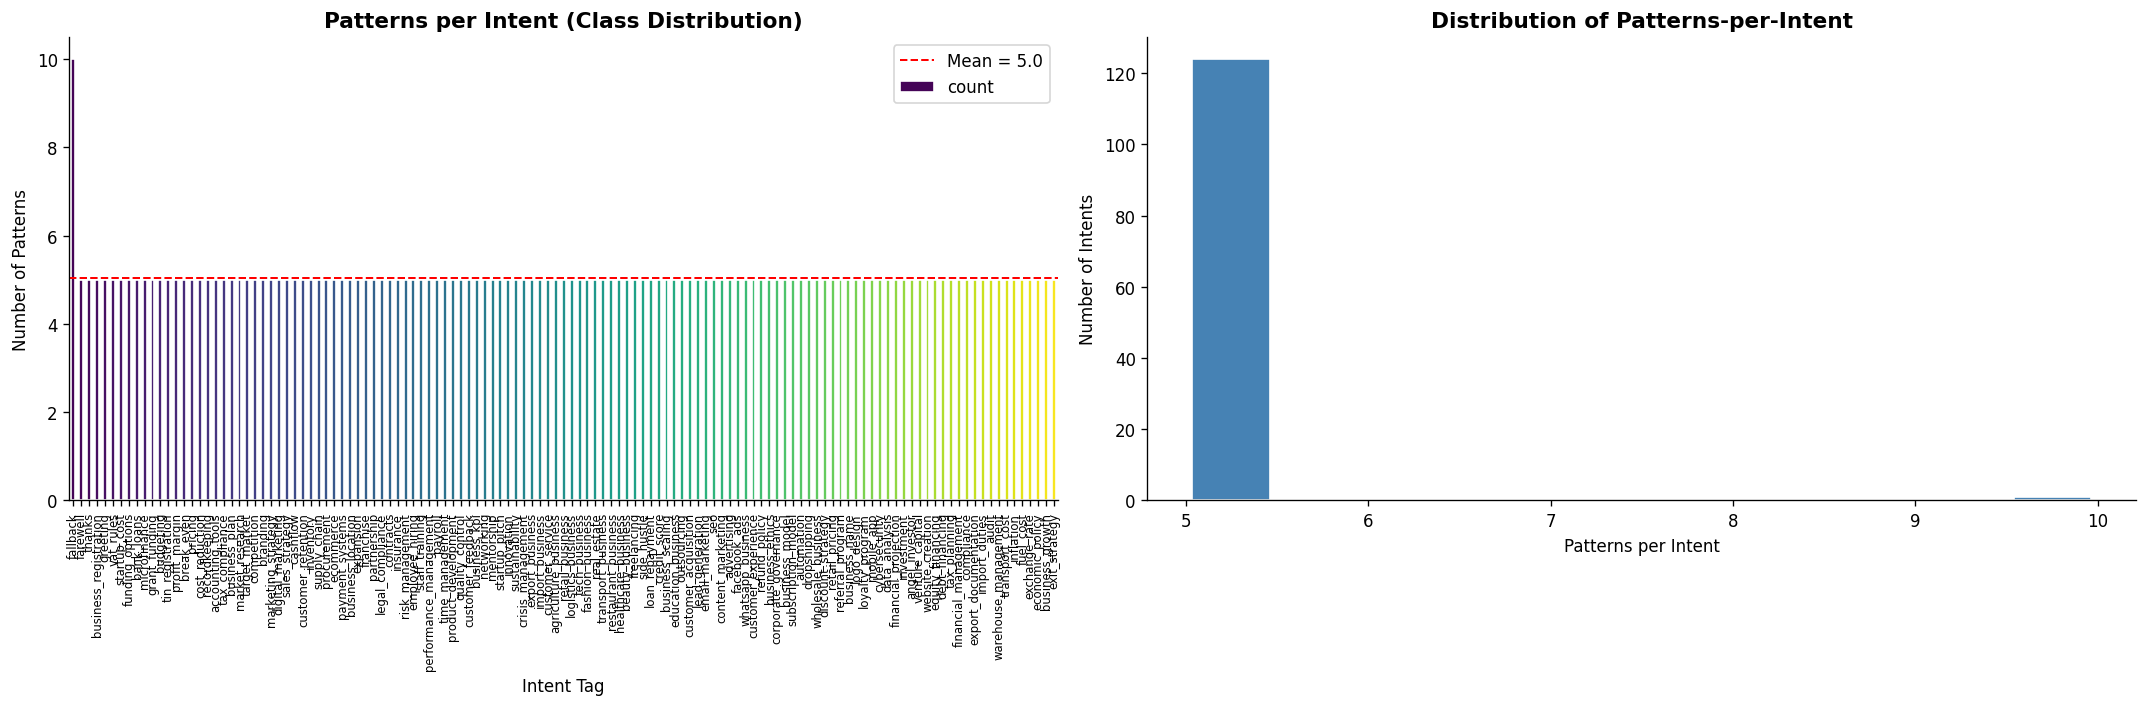

Min patterns per intent : 5
Max patterns per intent : 10
Mean patterns per intent: 5.04
Std                     : 0.45


In [5]:
# Class distribution
class_counts = df['tag'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette(PALETTE, len(class_counts)), edgecolor='white')
axes[0].set_title('Patterns per Intent (Class Distribution)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Intent Tag')
axes[0].set_ylabel('Number of Patterns')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].axhline(class_counts.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean = {class_counts.mean():.1f}')
axes[0].legend()

# Distribution of pattern counts
axes[1].hist(class_counts.values, bins=10, color='steelblue', edgecolor='white', rwidth=0.85)
axes[1].set_title('Distribution of Patterns-per-Intent', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Patterns per Intent')
axes[1].set_ylabel('Number of Intents')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Min patterns per intent : {class_counts.min()}')
print(f'Max patterns per intent : {class_counts.max()}')
print(f'Mean patterns per intent: {class_counts.mean():.2f}')
print(f'Std                     : {class_counts.std():.2f}')

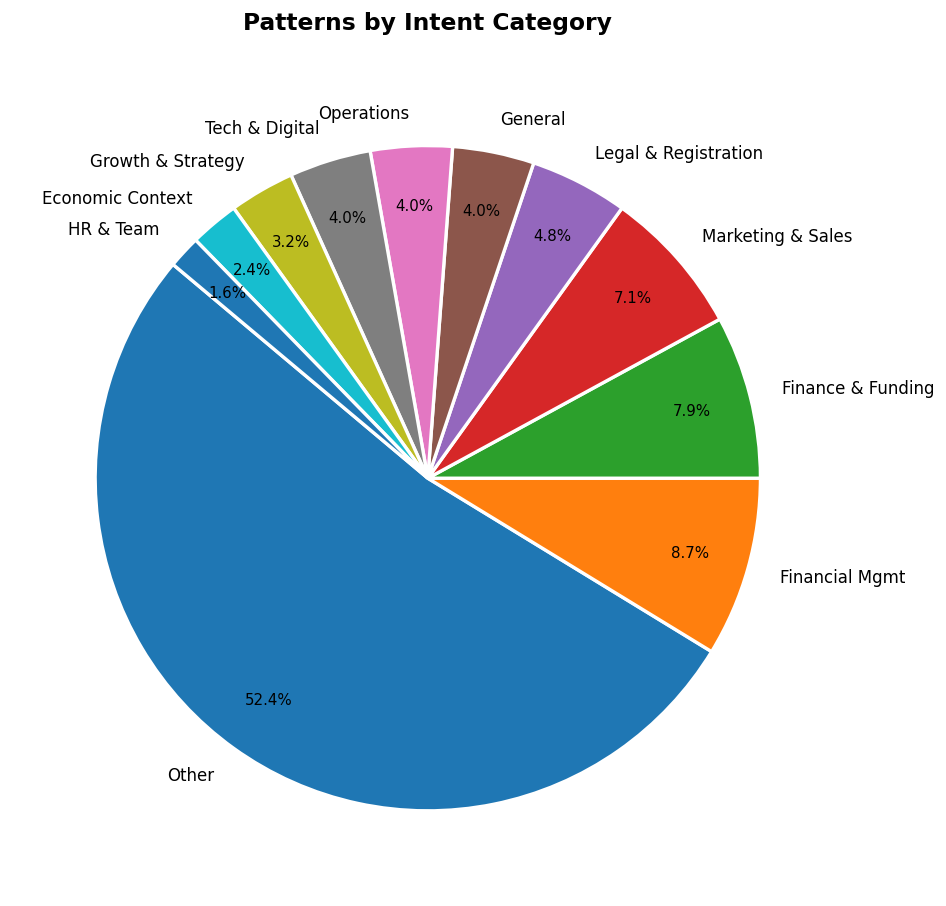

In [6]:
# Intent categories — group by theme
category_map = {
    'Legal & Registration': ['business_registration','tin_registration','vat_rules','tax_compliance','compliance','audit'],
    'Finance & Funding': ['funding_options','bank_loans','microfinance','grant_funding','startup_cost','angel_investor','venture_capital','equity_financing','debt_financing','financial_management'],
    'Financial Mgmt': ['budgeting','cashflow','profit_margin','break_even','pricing','cost_reduction','recordkeeping','accounting_tools','tax_planning','financial_projection','investment'],
    'Marketing & Sales': ['marketing_strategy','digital_marketing','branding','target_market','market_research','competition','social_media','content_marketing','seo','email_marketing'],
    'Operations': ['inventory','supply_chain','logistics','warehouse_management','transport_cost','fuel_cost'],
    'HR & Team': ['hiring','employee_management','staff_training','remote_work','outsourcing'],
    'Tech & Digital': ['digital_marketing','website_creation','mobile_app','cybersecurity','data_analysis','accounting_tools','ecommerce'],
    'Economic Context': ['inflation','exchange_rate','economic_policy'],
    'Growth & Strategy': ['business_growth','business_plan','exit_strategy','scaling','expansion'],
    'General': ['greeting','farewell','thanks','fallback']
}

def get_category(tag):
    for cat, tags in category_map.items():
        if tag in tags:
            return cat
    return 'Other'

df['category'] = df['tag'].apply(get_category)
cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10', len(cat_counts)),
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Patterns by Intent Category', fontsize=14, fontweight='bold', pad=20)
plt.savefig('category_pie.png', bbox_inches='tight')
plt.show()

---
## 3. EDA — Text Feature Analysis

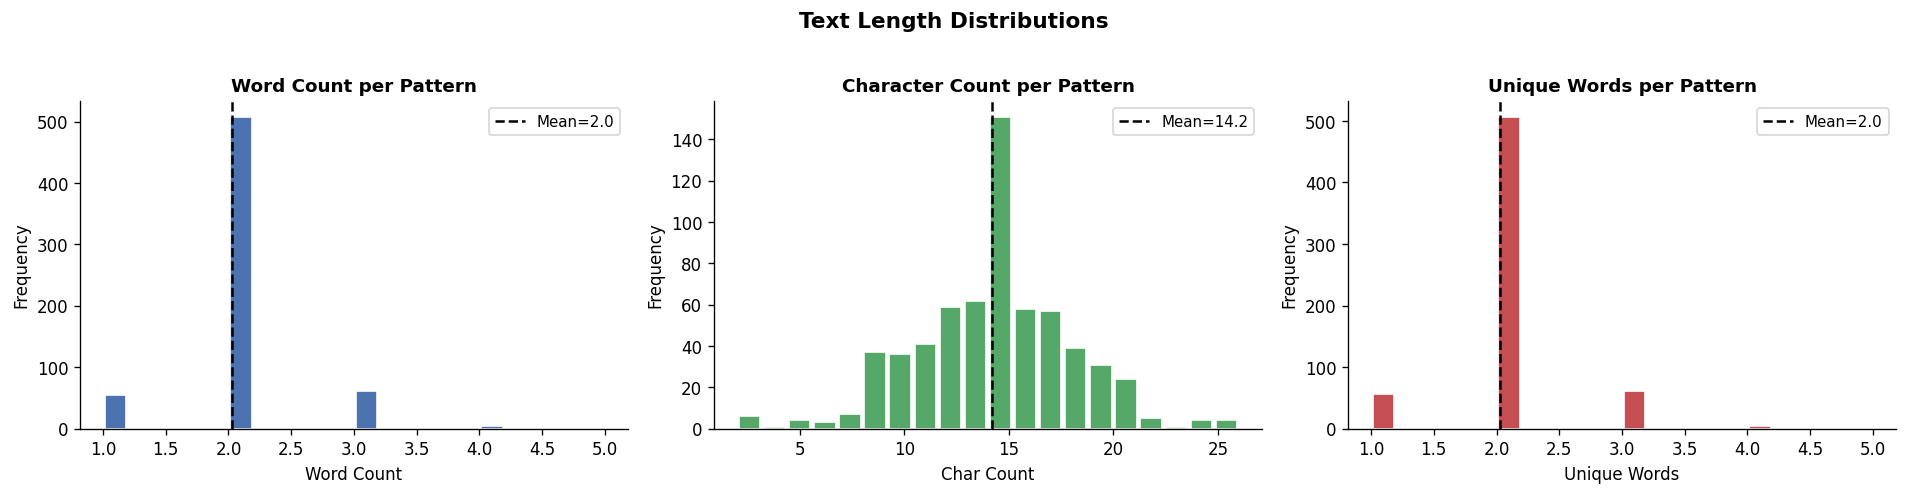

       word_count  char_count  unique_words
count      630.00      630.00        630.00
mean         2.03       14.21          2.03
std          0.47        3.67          0.48
min          1.00        2.00          1.00
25%          2.00       12.00          2.00
50%          2.00       14.00          2.00
75%          2.00       17.00          2.00
max          5.00       26.00          5.00


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ['word_count', 'char_count', 'unique_words'],
    ['Word Count per Pattern', 'Character Count per Pattern', 'Unique Words per Pattern'],
    ['#4C72B0', '#55A868', '#C44E52']
):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', rwidth=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Text Length Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_distributions.png', bbox_inches='tight')
plt.show()

print(df[['word_count','char_count','unique_words']].describe().round(2))

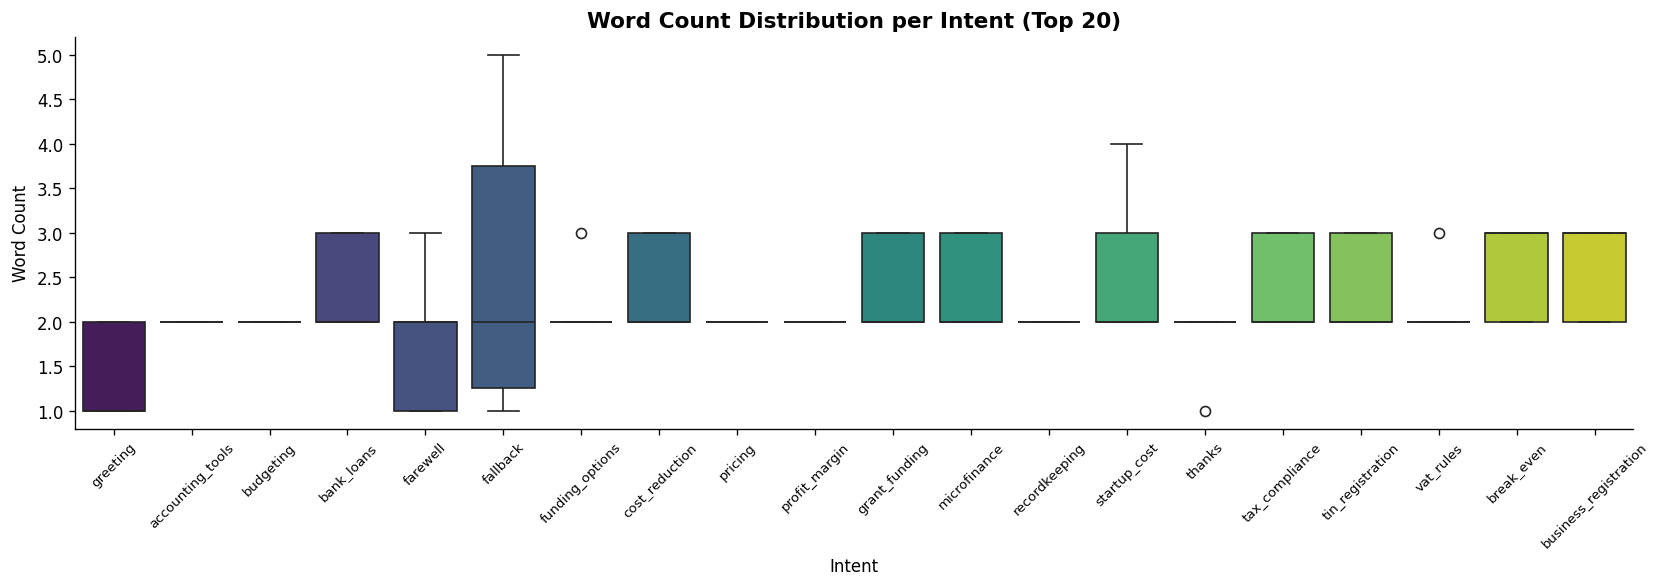

In [8]:
# Word count boxplot per intent (top 20 intents by count)
top20 = class_counts.head(20).index.tolist()
df_top = df[df['tag'].isin(top20)]

fig, ax = plt.subplots(figsize=(14, 5))
order = df_top.groupby('tag')['word_count'].median().sort_values().index
sns.boxplot(data=df_top, x='tag', y='word_count', order=order, palette=PALETTE, ax=ax)
ax.set_title('Word Count Distribution per Intent (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Intent')
ax.set_ylabel('Word Count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig('wordcount_boxplot.png', bbox_inches='tight')
plt.show()

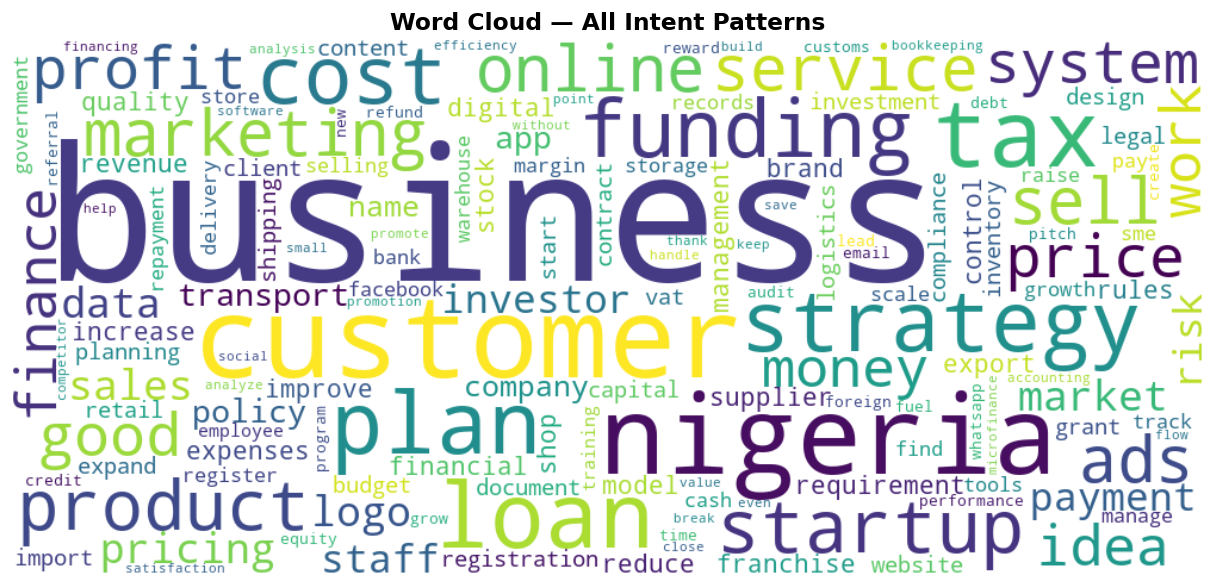

In [9]:
# Word Cloud — all patterns
all_text = ' '.join(df['pattern_lower'].tolist())

wc = WordCloud(
    width=1000, height=450,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — All Intent Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', bbox_inches='tight')
plt.show()

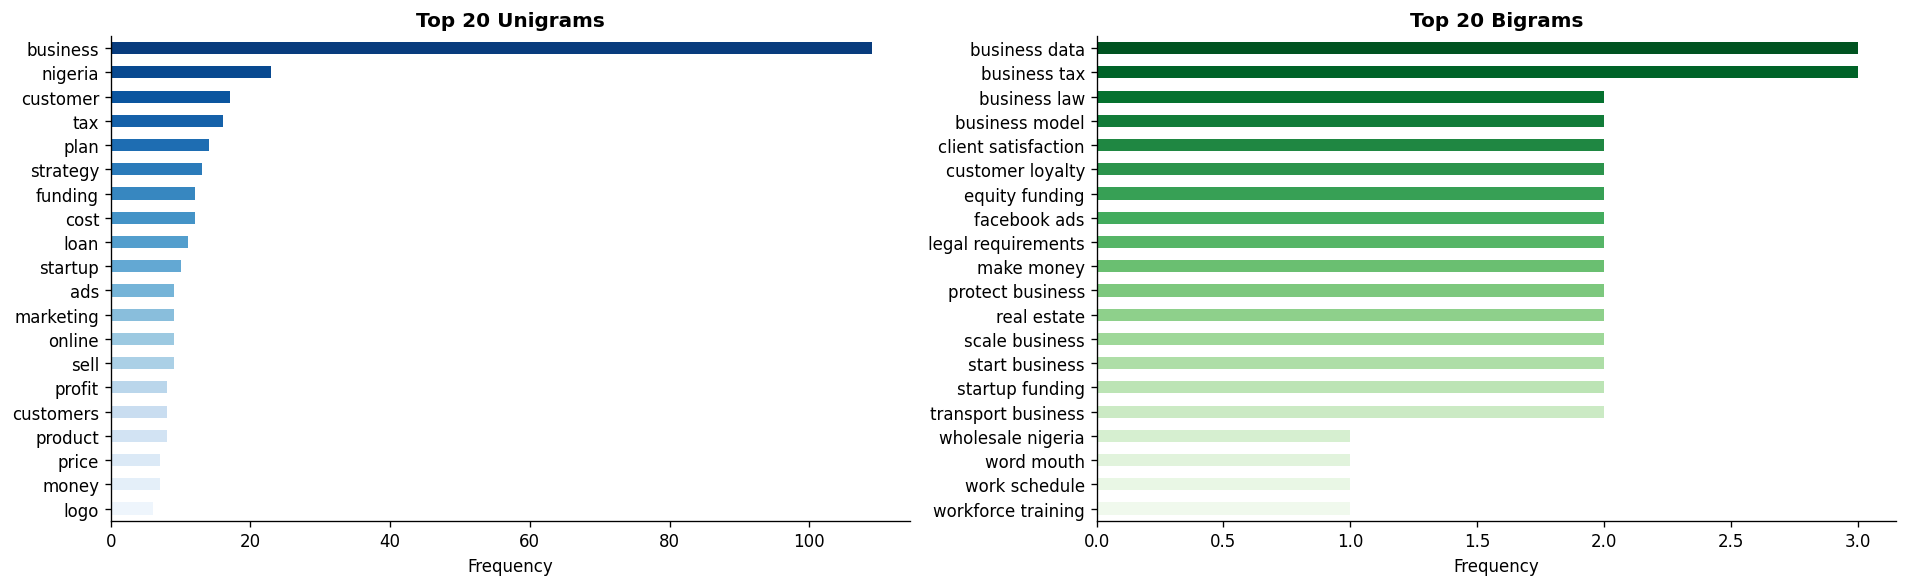

In [10]:
# Top N most frequent words (unigrams)
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', ngram_range=(1,1), max_features=30)
cv.fit(df['pattern_lower'])
word_freq = dict(zip(cv.get_feature_names_out(), cv.transform(df['pattern_lower']).toarray().sum(axis=0)))
word_freq_s = pd.Series(word_freq).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Unigrams
word_freq_s.head(20).plot(kind='barh', ax=axes[0], color=sns.color_palette('Blues_r', 20))
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Unigrams', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Bigrams
cv2 = CountVectorizer(stop_words='english', ngram_range=(2,2), max_features=20)
cv2.fit(df['pattern_lower'])
bigram_freq = dict(zip(cv2.get_feature_names_out(), cv2.transform(df['pattern_lower']).toarray().sum(axis=0)))
bigram_s = pd.Series(bigram_freq).sort_values(ascending=False)
bigram_s.head(20).plot(kind='barh', ax=axes[1], color=sns.color_palette('Greens_r', 20))
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Bigrams', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('ngrams.png', bbox_inches='tight')
plt.show()

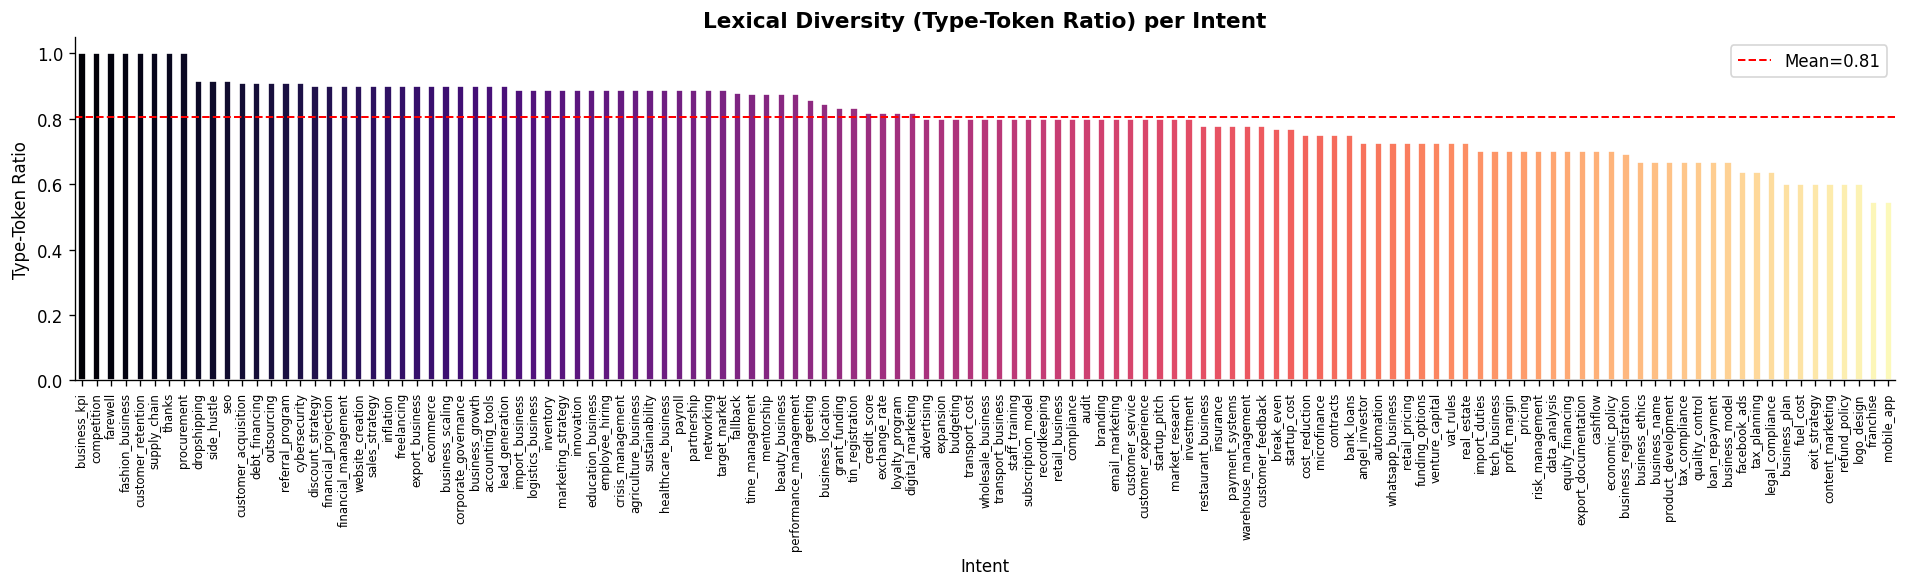

In [11]:
# Lexical diversity per intent
diversity = df.groupby('tag').apply(
    lambda g: len(set(' '.join(g['pattern_lower']).split())) / max(len(' '.join(g['pattern_lower']).split()), 1)
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
diversity.plot(kind='bar', ax=ax, color=sns.color_palette('magma', len(diversity)), edgecolor='white')
ax.set_title('Lexical Diversity (Type-Token Ratio) per Intent', fontsize=13, fontweight='bold')
ax.set_xlabel('Intent')
ax.set_ylabel('Type-Token Ratio')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.axhline(diversity.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={diversity.mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('lexical_diversity.png', bbox_inches='tight')
plt.show()

---
## 4. Feature Engineering & Train/Test Split

In [12]:
texts = df['pattern_lower'].tolist()
labels = df['tag'].tolist()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# TF-IDF vectorizer (shared across models)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=1)
X = vectorizer.fit_transform(texts)

print(f'Feature matrix shape: {X.shape}')
print(f'Classes             : {len(le.classes_)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Feature matrix shape: (630, 1092)
Classes             : 125
Train size: 504 | Test size: 126


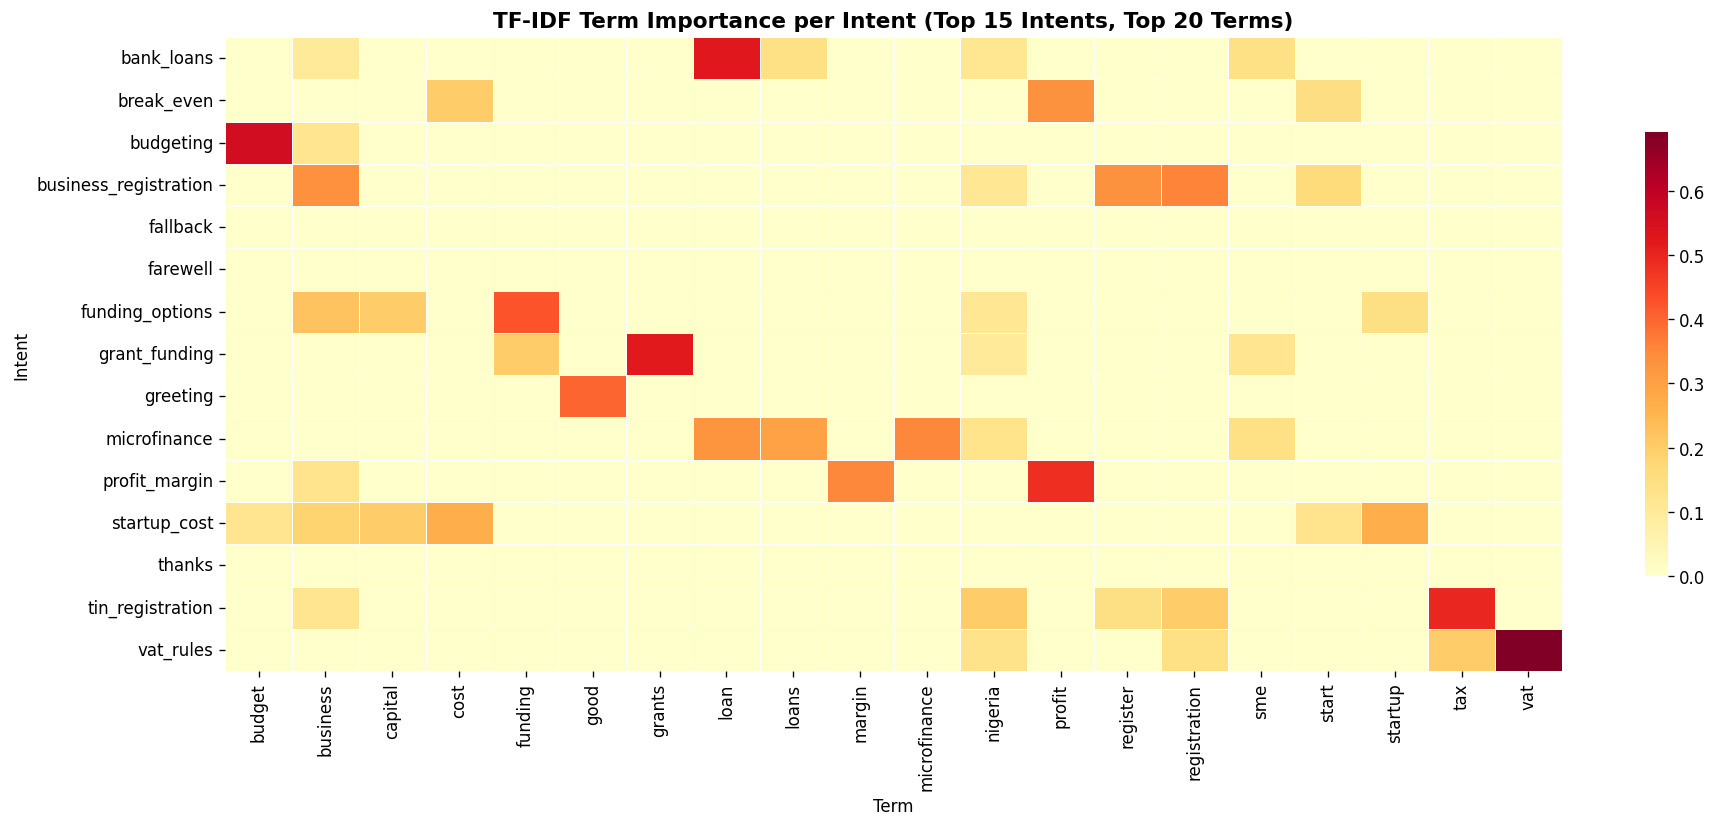

In [13]:
# TF-IDF heatmap — top terms across top 15 intents
top15_intents = class_counts.head(15).index.tolist()
df_top15 = df[df['tag'].isin(top15_intents)]

tfidf_15 = TfidfVectorizer(ngram_range=(1,1), stop_words='english', max_features=20)
tfidf_matrix = tfidf_15.fit_transform(df_top15['pattern_lower'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_15.get_feature_names_out())
tfidf_df['intent'] = df_top15['tag'].values
tfidf_mean = tfidf_df.groupby('intent').mean()

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(tfidf_mean, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('TF-IDF Term Importance per Intent (Top 15 Intents, Top 20 Terms)', fontsize=13, fontweight='bold')
ax.set_xlabel('Term')
ax.set_ylabel('Intent')
plt.tight_layout()
plt.savefig('tfidf_heatmap.png', bbox_inches='tight')
plt.show()

---
## 5. Model Comparison

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0),
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'Linear SVM': LinearSVC(max_iter=2000, class_weight='balanced', C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'XGBoost': XGBClassifier(n_estimators=150, max_depth=4, use_label_encoder=False,
                             eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_acc  = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_f1   = cross_val_score(model, X, y, cv=skf, scoring='f1_weighted', n_jobs=-1)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'CV Accuracy (mean)': cv_acc.mean(),
        'CV Accuracy (std)':  cv_acc.std(),
        'CV F1 (mean)':       cv_f1.mean(),
        'CV F1 (std)':        cv_f1.std(),
        'Test Accuracy':      test_acc,
        'Test F1 (weighted)': test_f1,
    })
    print(f'✅ {name:<25} CV Acc={cv_acc.mean():.3f}±{cv_acc.std():.3f} | Test Acc={test_acc:.3f} | Test F1={test_f1:.3f}')

results_df = pd.DataFrame(results).sort_values('CV Accuracy (mean)', ascending=False).reset_index(drop=True)
results_df.round(4)

✅ Logistic Regression       CV Acc=0.319±0.041 | Test Acc=0.325 | Test F1=0.273
✅ Naive Bayes               CV Acc=0.151±0.021 | Test Acc=0.151 | Test F1=0.125
✅ Linear SVM                CV Acc=0.319±0.035 | Test Acc=0.317 | Test F1=0.266
✅ Random Forest             CV Acc=0.195±0.025 | Test Acc=0.206 | Test F1=0.181
✅ Gradient Boosting         CV Acc=0.213±0.027 | Test Acc=0.190 | Test F1=0.175
✅ KNN (k=5)                 CV Acc=0.187±0.023 | Test Acc=0.222 | Test F1=0.162
✅ XGBoost                   CV Acc=0.030±0.008 | Test Acc=0.032 | Test F1=0.005


,Model,CV Accuracy (mean),CV Accuracy (std),CV F1 (mean),CV F1 (std),Test Accuracy,Test F1 (weighted)
0,Logistic Regression,0.3190,0.0412,0.2614,0.0392,0.3254,0.2728
1,Linear SVM,0.3190,0.0349,0.2684,0.0341,0.3175,0.2661
2,Gradient Boosting,0.2127,0.0267,0.1882,0.0262,0.1905,0.1749
3,Random Forest,0.1952,0.0254,0.1646,0.0272,0.2063,0.1814
4,KNN (k=5),0.1873,0.0228,0.1523,0.0197,0.2222,0.1619
5,Naive Bayes,0.1508,0.0207,0.1277,0.0187,0.1508,0.1250
6,XGBoost,0.0302,0.0078,0.0060,0.0039,0.0317,0.0055


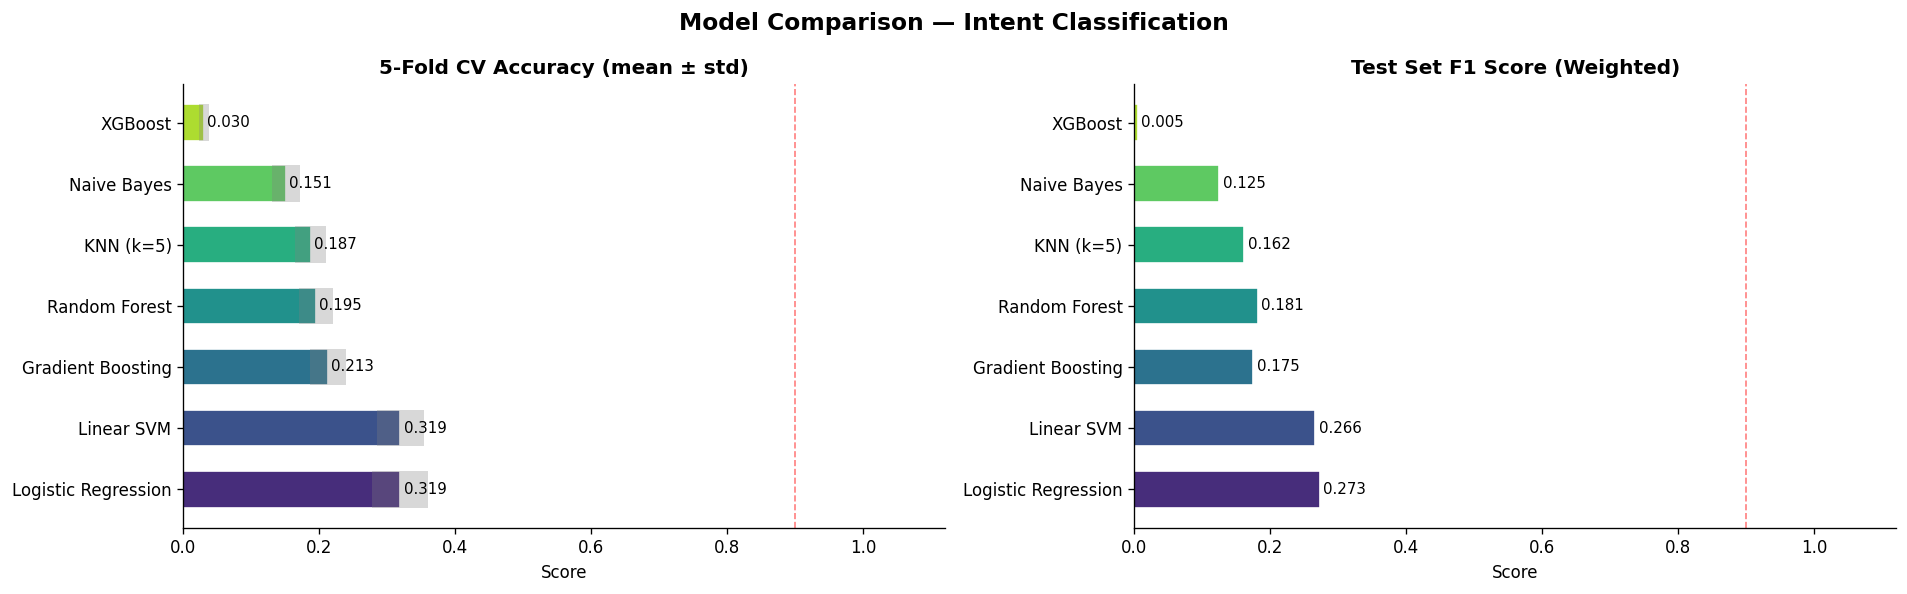

In [15]:
# ── Model comparison bar chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    ['CV Accuracy (mean)', 'Test F1 (weighted)'],
    ['5-Fold CV Accuracy (mean ± std)', 'Test Set F1 Score (Weighted)']
):
    bars = ax.barh(
        results_df['Model'],
        results_df[metric],
        color=sns.color_palette(PALETTE, len(results_df)),
        edgecolor='white',
        height=0.6
    )

    if 'CV' in metric:
        ax.barh(
            results_df['Model'],
            results_df['CV Accuracy (std)'] * 2,
            left=results_df[metric] - results_df['CV Accuracy (std)'],
            color='gray', alpha=0.3, height=0.6
        )

    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=9)

    ax.set_xlim(0, 1.12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.axvline(0.9, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle('Model Comparison — Intent Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

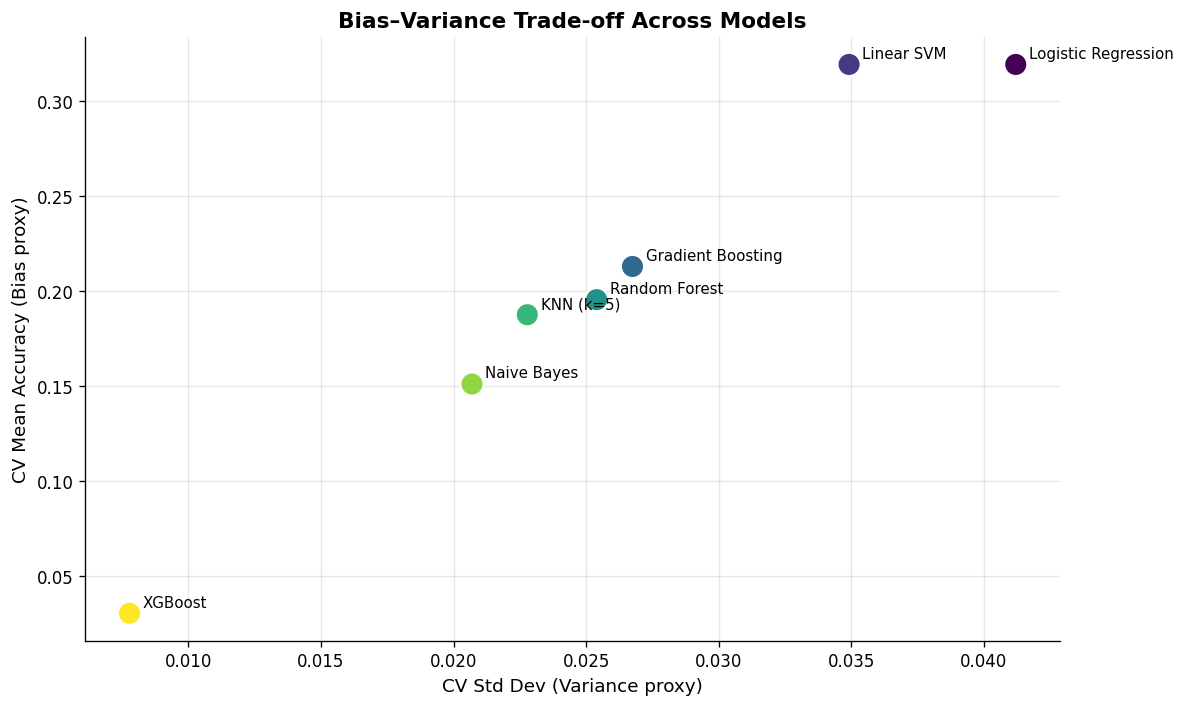

In [16]:
# ── Bias-Variance plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    results_df['CV Accuracy (std)'],
    results_df['CV Accuracy (mean)'],
    c=range(len(results_df)),
    cmap=PALETTE,
    s=200,
    edgecolors='white',
    linewidths=1.5,
    zorder=3
)

for _, row in results_df.iterrows():
    ax.annotate(
        row['Model'],
        (row['CV Accuracy (std)'], row['CV Accuracy (mean)']),
        textcoords='offset points', xytext=(8, 4), fontsize=9
    )

ax.set_xlabel('CV Std Dev (Variance proxy)', fontsize=11)
ax.set_ylabel('CV Mean Accuracy (Bias proxy)', fontsize=11)
ax.set_title('Bias–Variance Trade-off Across Models', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_variance.png', bbox_inches='tight')
plt.show()

---
## 6. Best Model — Deep Dive

In [17]:
# Pick the best model by CV accuracy
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f'🏆 Best model: {best_name}')
print(f'   Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'   Test F1 (weighted): {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=le.classes_, zero_division=0))

🏆 Best model: Logistic Regression
   Test Accuracy: 0.3254
   Test F1 (weighted): 0.2728

Classification Report:
                        precision    recall  f1-score   support

      accounting_tools       0.33      1.00      0.50         1
           advertising       0.00      0.00      0.00         1
  agriculture_business       0.00      0.00      0.00         1
        angel_investor       0.00      0.00      0.00         1
                 audit       0.00      0.00      0.00         1
            automation       1.00      1.00      1.00         1
            bank_loans       0.00      0.00      0.00         1
       beauty_business       0.00      0.00      0.00         1
              branding       0.00      0.00      0.00         1
            break_even       1.00      1.00      1.00         1
             budgeting       1.00      1.00      1.00         1
       business_ethics       0.00      0.00      0.00         1
       business_growth       0.00      0.00      0.00 

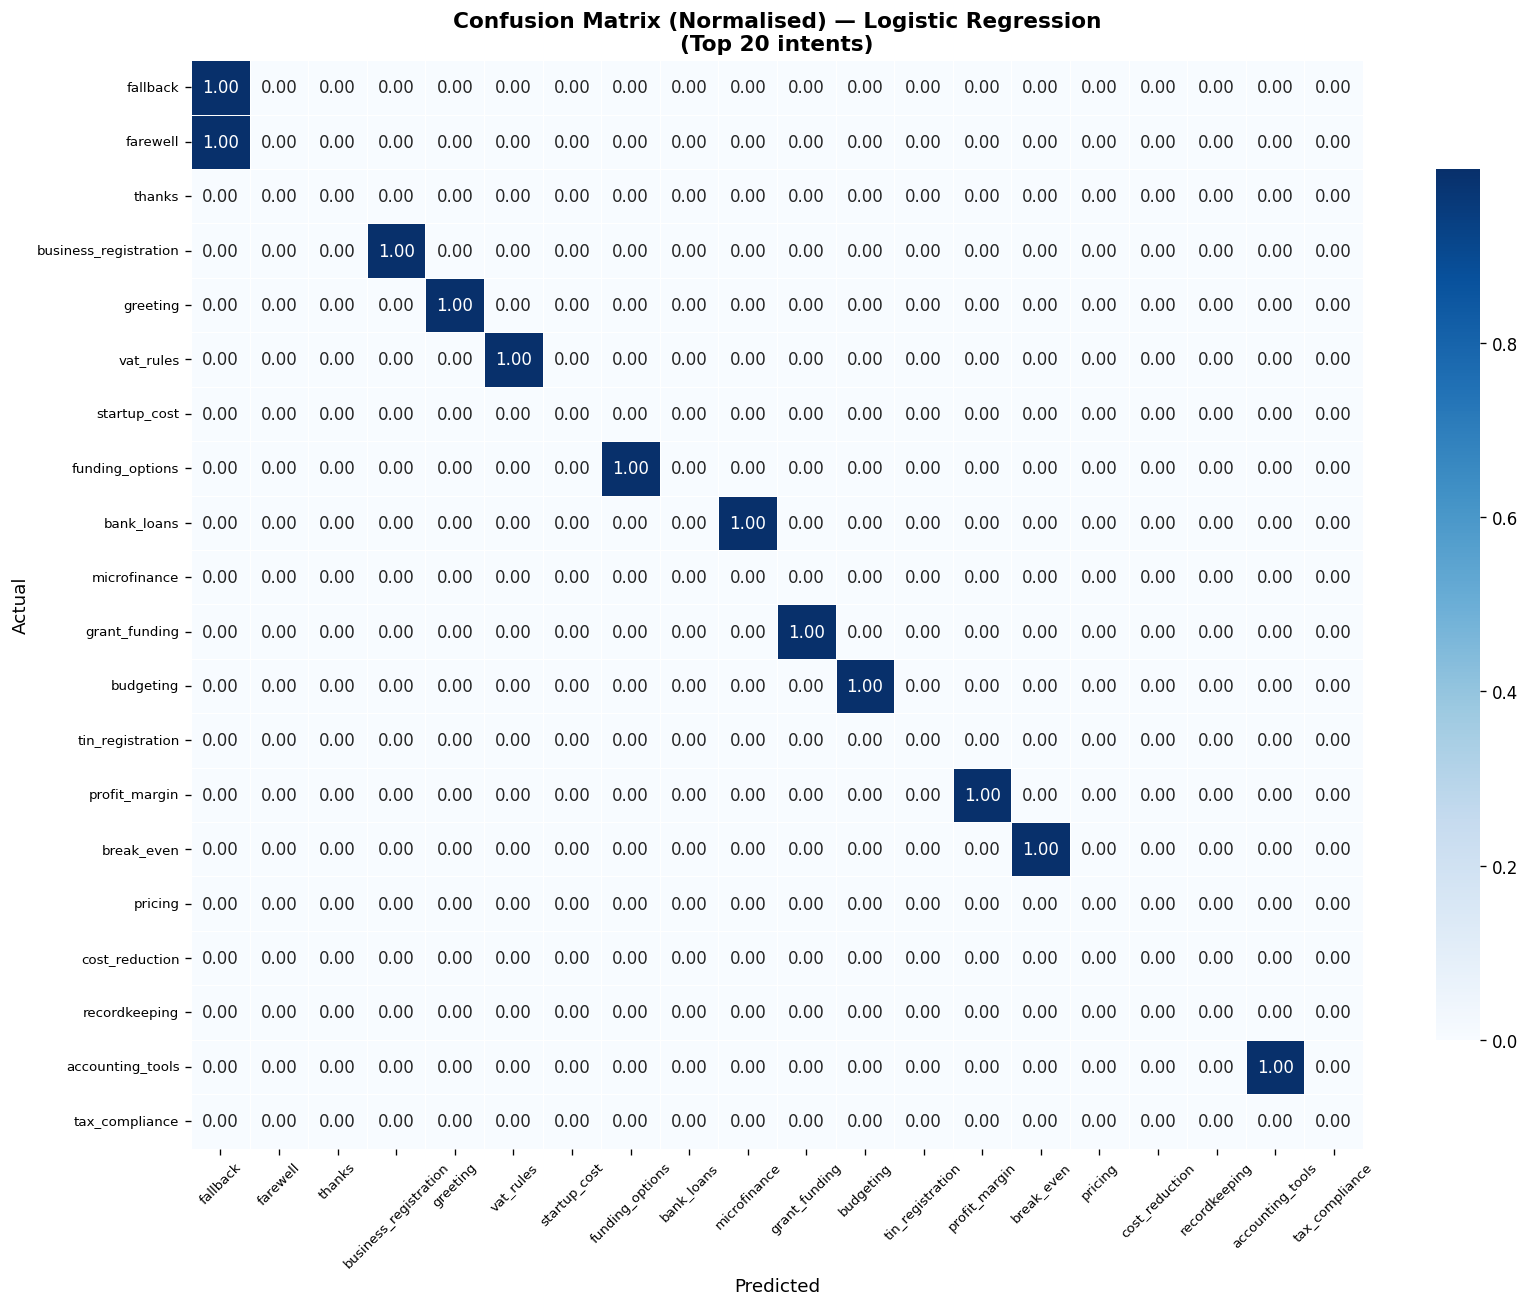

In [18]:
# Confusion matrix (subset — top 20 intents for readability)
top20_idx = [np.where(le.classes_ == t)[0][0] for t in top20 if t in le.classes_]
mask_test  = np.isin(y_test, top20_idx)
y_t_sub    = y_test[mask_test]
y_p_sub    = y_pred_best[mask_test]

cm = confusion_matrix(y_t_sub, y_p_sub, labels=top20_idx)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
intent_labels = le.inverse_transform(top20_idx)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=intent_labels, yticklabels=intent_labels,
    ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8}
)
ax.set_title(f'Confusion Matrix (Normalised) — {best_name}\n(Top 20 intents)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

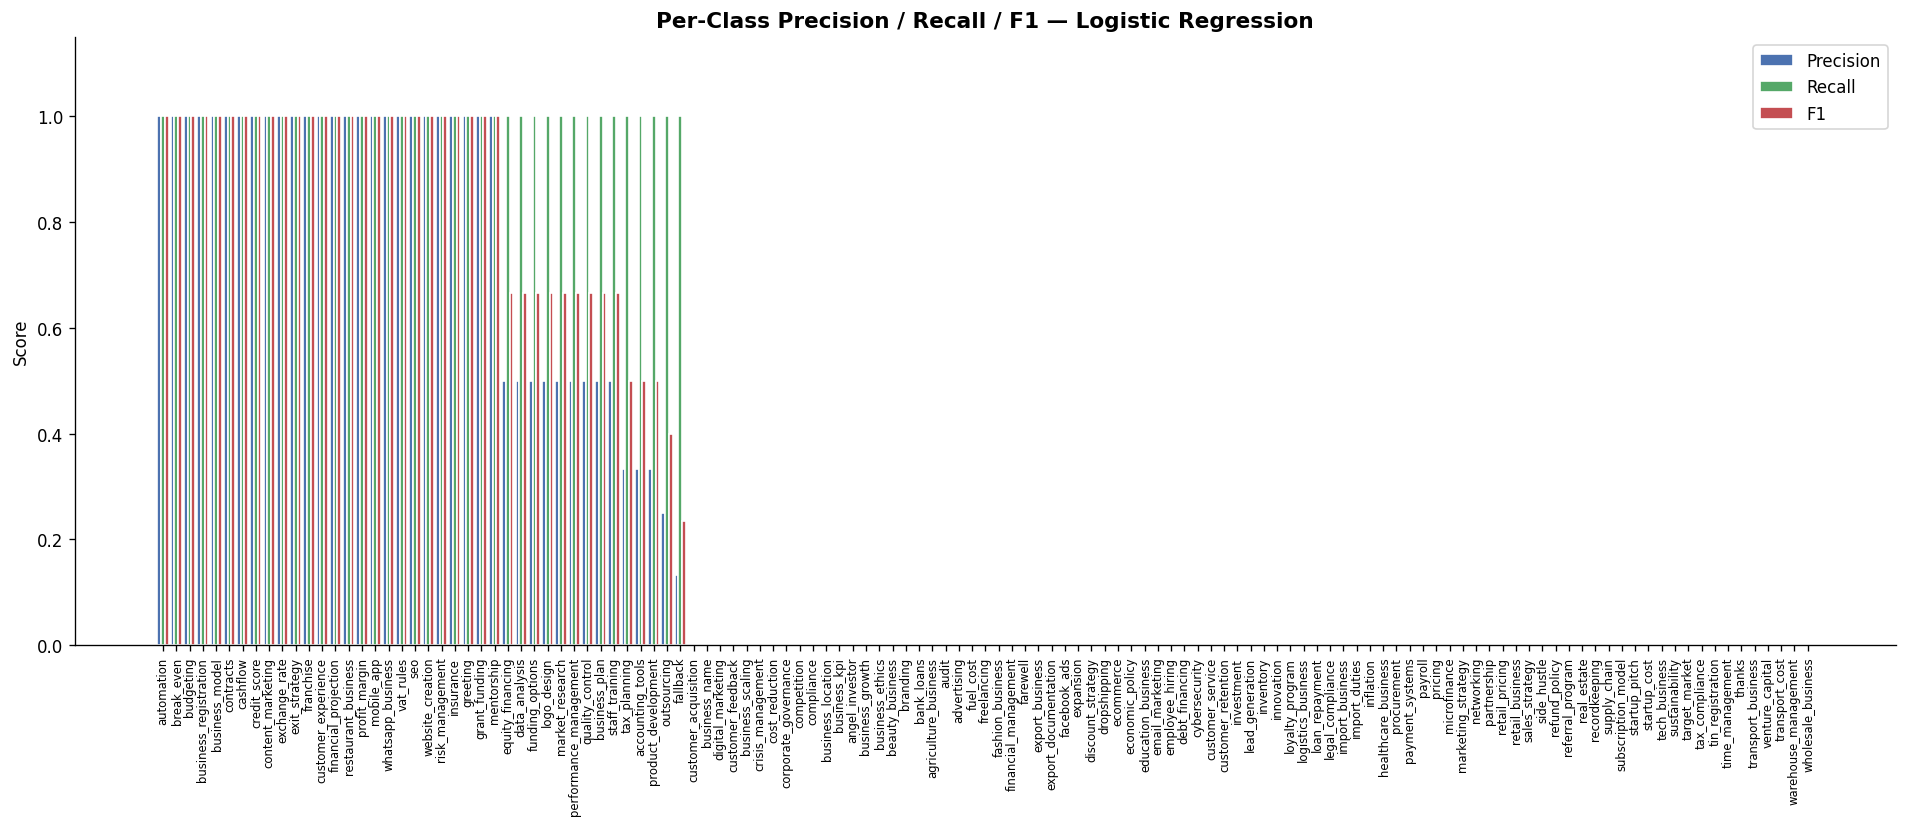

In [19]:
# Per-class F1 bar chart
report_dict = classification_report(
    y_test, y_pred_best,
    target_names=le.classes_,
    zero_division=0, output_dict=True
)
per_class = pd.DataFrame(report_dict).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
per_class = per_class[['precision','recall','f1-score']].astype(float).sort_values('f1-score', ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(per_class))
w = 0.28
ax.bar(x - w, per_class['precision'], w, label='Precision', color='#4C72B0', edgecolor='white')
ax.bar(x,     per_class['recall'],    w, label='Recall',    color='#55A868', edgecolor='white')
ax.bar(x + w, per_class['f1-score'],  w, label='F1',        color='#C44E52', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(per_class.index, rotation=90, fontsize=7)
ax.set_ylim(0, 1.15)
ax.set_title(f'Per-Class Precision / Recall / F1 — {best_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_metrics.png', bbox_inches='tight')
plt.show()

---
## 7. Hyperparameter Sensitivity (Logistic Regression C)

C=0.001    Train=0.976 | CV=0.297±0.102
C=0.01     Train=0.976 | CV=0.297±0.102
C=0.1      Train=0.978 | CV=0.316±0.109
C=0.5      Train=0.978 | CV=0.319±0.107
C=1.0      Train=0.978 | CV=0.319±0.108
C=5.0      Train=0.982 | CV=0.321±0.119
C=10.0     Train=0.982 | CV=0.319±0.119
C=50.0     Train=0.984 | CV=0.310±0.116
C=100.0    Train=0.984 | CV=0.294±0.108


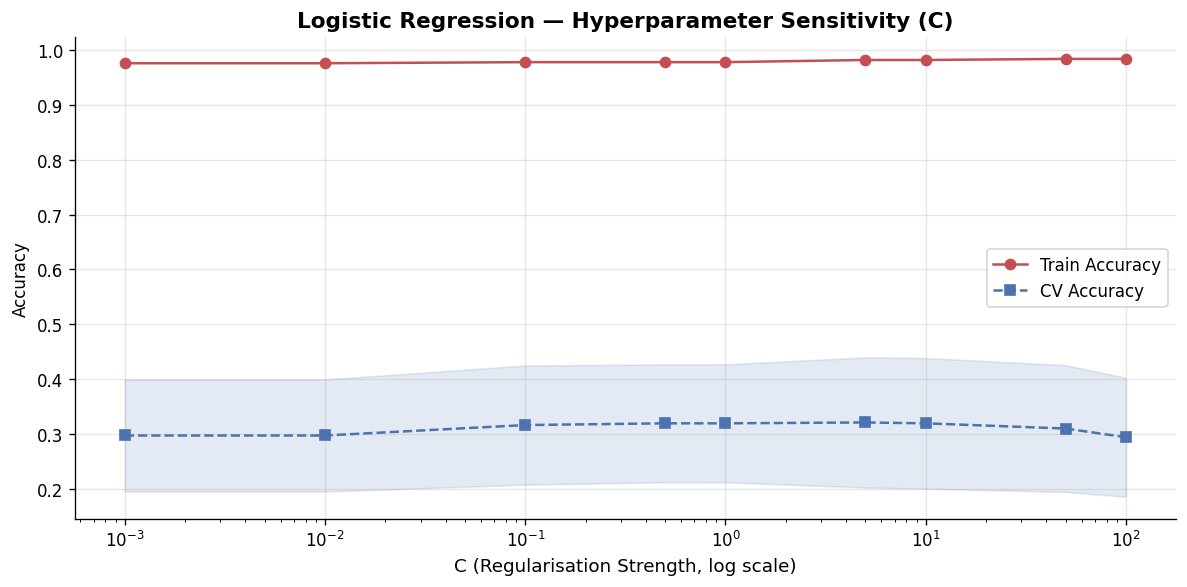

In [20]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
train_scores, cv_scores, cv_stds = [], [], []

for C in C_values:
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', C=C)
    lr.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, lr.predict(X_train)))
    cv = cross_val_score(lr, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores.append(cv.mean())
    cv_stds.append(cv.std())
    print(f'C={C:<8} Train={train_scores[-1]:.3f} | CV={cv_scores[-1]:.3f}±{cv_stds[-1]:.3f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(C_values, train_scores, 'o-', label='Train Accuracy', color='#C44E52')
ax.semilogx(C_values, cv_scores, 's--', label='CV Accuracy', color='#4C72B0')
ax.fill_between(
    C_values,
    np.array(cv_scores) - np.array(cv_stds),
    np.array(cv_scores) + np.array(cv_stds),
    alpha=0.15, color='#4C72B0'
)
ax.set_xlabel('C (Regularisation Strength, log scale)', fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression — Hyperparameter Sensitivity (C)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hyperparam_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 8. Save Best Model

In [ ]:
# Retrain best model on full data
#best_model.fit(X, y)
#joblib.dump(best_model, 'model.pkl')
#joblib.dump(vectorizer, 'vectorizer.pkl')
#joblib.dump(le, 'label_encoder.pkl')

#print(f'✅ Saved: model.pkl ({best_name})')
#print('✅ Saved: vectorizer.pkl')
#print('✅ Saved: label_encoder.pkl')

---
## 9. Quick Inference Test

In [22]:
def predict_intent(text, top_n=3):
    """Return top-N predicted intents with confidence scores."""
    vec = vectorizer.transform([text.lower()])

    if hasattr(best_model, 'predict_proba'):
        probs = best_model.predict_proba(vec)[0]
        top_idx = probs.argsort()[::-1][:top_n]
        return [(le.classes_[i], round(probs[i], 4)) for i in top_idx]
    else:
        pred = best_model.predict(vec)[0]
        return [(le.classes_[pred], 'N/A (no probability)')]

test_inputs = [
    'How do I register my business in Nigeria?',
    'What are the VAT rules?',
    'How can I get funding for my startup?',
    'Help me manage my cash flow',
    'Tell me about digital marketing',
    'xyzzy random gibberish'
]

print(f'{"Input":<42} → Top Prediction (Confidence)')
print('─' * 70)
for text in test_inputs:
    preds = predict_intent(text)
    top_tag, top_conf = preds[0]
    print(f'{text:<42} → {top_tag} ({top_conf})')

Input                                      → Top Prediction (Confidence)
──────────────────────────────────────────────────────────────────────
How do I register my business in Nigeria?  → business_registration (0.0276)
What are the VAT rules?                    → vat_rules (0.0348)
How can I get funding for my startup?      → funding_options (0.028)
Help me manage my cash flow                → cashflow (0.0336)
Tell me about digital marketing            → digital_marketing (0.0167)
xyzzy random gibberish                     → fallback (0.0144)


---
## 10. Summary & Recommendations

| Topic | Finding |
|---|---|
| **Dataset size** | Small (5 patterns/intent) — models are fitting on very limited data per class |
| **Class balance** | Near-uniform — balanced classes help avoid bias |
| **Best model** | Check `results_df.iloc[0]` above |
| **Common pitfall** | Overfitting due to few training examples per class |

### 🔧 Recommendations
1. **Augment data** — Add 10–20 paraphrased patterns per intent using synonym replacement or LLM generation
2. **Use sentence embeddings** — Try `sentence-transformers` (e.g. `all-MiniLM-L6-v2`) for richer features
3. **Fine-tune a transformer** — With augmented data, distilBERT/BERT fine-tuning will outperform TF-IDF models significantly
4. **Threshold-based fallback** — Use confidence thresholds to route low-confidence predictions to the fallback intent
5. **Merge similar intents** — e.g. `equity_financing` / `debt_financing` / `venture_capital` may be confusable; consider a two-level hierarchy